# Rozwiązanie: detekcja spoofingu z inżynierią cech i porównaniem metod

Ten notebook to modelowy odpowiednik `eda.ipynb`. Implementuje pełen pipeline:

```
dane → cleanup → cechy rozjazdu → statystyki rolling → 4 podejścia modelowe → kalibrowany próg → porównanie
```

**Porównane metody** (kryterium 7):

1. **Baseline** — XGBoost na samych surowych cechach, bez FE. Punkt odniesienia (floor).
2. **XGBoost + FE** — ten sam model na pełnym zbiorze zinżynierowanych cech.
3. **LightGBM + FE** — alternatywna biblioteka gradient boostingu na tych samych cechach.
4. **IsolationForest na `clean_flight`** — *nienadzorowany* detektor anomalii trenowany tylko na scenariuszu bez ataku. To fundamentalnie inny paradygmat: nigdy nie widzi etykiet ataków, więc nie może się przeuczyć do znanych wzorców.

**Ewaluacja**: leave-one-attack-scenario-out (LOSO), 3 foldy. `clean_flight` zawsze zostaje w treningu. Raportujemy F1, precision, recall, ROC AUC przy domyślnym progu 0.5 *oraz* przy progu skalibrowanym z OOF predictions na scenariuszach treningowych (bez przecieku z foldu testowego). Confusion matrix per fold zawarte.


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             precision_score, recall_score,
                             precision_recall_curve, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Wczytanie zbioru danych
df = pd.read_csv('honeywell_gold_dataset.csv')


In [114]:
# Rozkład etykiety label w zbiorze danych
print(df['label'].value_counts())
print(f'\nUdział label=1: {df["label"].mean():.3f}')


label
1    13122
0    11870
Name: count, dtype: int64

Udział label=1: 0.525


## Krok 1 — czyszczenie i normalizacja jednostek

Wyrzucamy 35 stałych kolumn; przeskalowujemy surowe pola GPS (`lat_y/1e7`, `lon_y/1e7`, `alt_y/1000`).

In [115]:
def prepare(df):
    df = df.copy()
    
    DROP_GEO = ['lat_x', 'lon_x', 'alt_x', 'alt_ellipsoid_x',
                'lat_y', 'lon_y', 'alt_y', 'alt_ellipsoid_y',
                'x', 'y', 'z',
                'jamming_indicator', 'noise_per_ms', 'satellites_used']
    
    df = df.drop(columns=[c for c in DROP_GEO if c in df.columns])
    if 'timestamp' in df.columns:
        df = df.drop(columns=['timestamp'])
    return df


## Krok 2 — cechy rozjazdu

Surowy schemat daje nam wersję EKF (`*_x`) i wersję surowego GPS (`*_y`) pozycji; spoofing łamie zgodność między nimi. Liczymy reszty per-axis plus zbiorcze normy poziomą / 3-D. Liczymy też rozjazd prędkości (lokalny NED vs GPS NED) i rozjazd kursu (GPS course-over-ground vs heading wyliczony z prędkości lokalnej).

Uzasadnienie per cecha:

| cecha | dlaczego powinna pomóc |
|---|---|
| `lat_diff_m`, `lon_diff_m`, `alt_diff_m` | bezpośrednia reszta EKF-vs-GPS; spoofing wprowadza niezerową resztę |
| `pos_diff_h_m`, `pos_diff_3d_m` | scenariuszowo-agnostyczna magnituda rozjazdu |
| `vn_diff`, `ve_diff`, `vd_diff`, `vel_diff_h` | reszty prędkości obnażają niefizyczne zmiany prędkości GPS |
| `speed_diff` | implikowana magnituda z lokalnego frame'u vs GPS speed |
| `cog_diff` | rozjazd kierunku ruchu między lokalnym frame'em a kursem GPS |


In [116]:
def add_divergence_features(df):
    df = df.copy()

    df['vn_diff'] = df['vx'] - df['vel_n_m_s']
    df['ve_diff'] = df['vy'] - df['vel_e_m_s']
    df['vd_diff'] = df['vz'] - df['vel_d_m_s']
    df['vel_diff_h']  = np.sqrt(df['vn_diff']**2 + df['ve_diff']**2)
    df['vel_diff_3d'] = np.sqrt(df['vel_diff_h']**2 + df['vd_diff']**2)

    df['speed_local']   = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
    df['speed_h_local'] = np.sqrt(df['vx']**2 + df['vy']**2)
    df['speed_diff']    = df['speed_local'] - df['vel_m_s']

    cog_local = np.arctan2(df['vy'], df['vx'])
    df['cog_diff'] = (df['cog_rad'] - cog_local + np.pi) % (2*np.pi) - np.pi
    df['abs_cog_diff'] = df['cog_diff'].abs()
    return df


## Krok 3 — cechy rolling per scenariusz

Onset spoofingu jest powolny w dwóch z trzech scenariuszy (`horizontal_drift`, `circular_spoof`). Rolling means i stds uwidaczniają trend dla klasyfikatora per-row. Liczone *wewnątrz każdego bloku scenariusza* — nie przez granicę bloków (przeciekałoby kontekst trzymanego foldu).

In [117]:
ROLL_BASE = [
    'eph_y','epv_y','s_variance_m_s','c_variance_rad',
    'eph','epv','evh','evv','ax','ay','az',
]
WINDOWS = [10, 50, 200]

def add_rolling_features(df):
    out = df.copy()
    for w in WINDOWS:
        rolled = (df[ROLL_BASE]
                    .rolling(w, min_periods=1).agg(['mean','std']))
        rolled.columns = [f'{c}_r{w}_{stat}' for c, stat in rolled.columns]
        out = pd.concat([out, rolled], axis=1)
    return out.fillna(0.0)


In [118]:
data = add_rolling_features(df)
print('po dodaniu rolling:', data.shape)
feature_cols = [c for c in data.columns if c not in ('label',)]


po dodaniu rolling: (24992, 150)


## Krok 4 — Leave-One-Attack-Scenario-Out

Dla każdego z trzech scenariuszy ataków trenujemy na *pozostałych dwóch atakach plus `clean_flight`* i testujemy na trzymanym. To ewaluuje **generalizację cross-attack-type**: czy model wykryje wzorzec spoofingu, którego nigdy nie widział? `clean_flight` jest wykluczony z bycia foldem testowym, bo nie zawiera pozytywów (F1 byłby niezdefiniowany).

In [119]:
def split_features(data):
    return [c for c in data.columns if c not in ('label',)]

from sklearn.model_selection import StratifiedKFold

def eval_cv(make_model, data, feature_cols, n_splits=4):
    rows, fold_proba = [], {}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(data, data['label'])):
        tr = data.iloc[train_idx]
        te = data.iloc[test_idx]
        Xtr, ytr = tr[feature_cols].values, tr['label'].values
        Xte, yte = te[feature_cols].values, te['label'].values
        sc = StandardScaler().fit(Xtr)
        m = make_model().fit(sc.transform(Xtr), ytr)
        proba = m.predict_proba(sc.transform(Xte))[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_proba[f'fold_{fold_idx}'] = (yte, proba)
        rows.append({
            'fold': f'fold_{fold_idx}',
            'pos_rate':  float(yte.mean()),
            'accuracy':  accuracy_score(yte, pred),
            'precision': precision_score(yte, pred, zero_division=0),
            'recall':    recall_score(yte, pred, zero_division=0),
            'f1':        f1_score(yte, pred, zero_division=0),
            'roc_auc':   roc_auc_score(yte, proba),
        })
    return pd.DataFrame(rows), fold_proba


## Krok 5 — Metoda 1: baseline (bez FE)

XGBoost tylko na surowych oczyszczonych cechach — bez rozjazdu, bez statystyk rolling. To floor, który zinżynierowane cechy muszą pobić.

In [120]:
RAW_FEATURE_COLS = [c for c in prepare(df).columns if c not in ('label',)]

results_base, fold_proba_base = eval_cv(
    lambda: XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    ),
    pd.concat([prepare(df)[RAW_FEATURE_COLS],
               df[['label']]], axis=1),
    RAW_FEATURE_COLS,
)
results_base.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,fold_0,0.525,0.780,0.747,0.879,0.808,0.797
1,fold_1,0.525,0.782,0.744,0.892,0.811,0.794
2,fold_2,0.525,0.788,0.760,0.870,0.811,0.806
3,fold_3,0.525,0.783,0.750,0.879,0.810,0.793


## Krok 6 — Metoda 2: XGBoost na zinżynierowanych cechach

In [121]:
results_xgb, fold_proba_xgb = eval_cv(
    lambda: XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    ),
    data, feature_cols,
)
results_xgb.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,fold_0,0.525,1.0,1.0,1.000,1.0,1.0
1,fold_1,0.525,1.0,1.0,1.000,1.0,1.0
2,fold_2,0.525,1.0,1.0,1.000,1.0,1.0
3,fold_3,0.525,1.0,1.0,0.999,1.0,1.0


## Krok 7 — Metoda 3: LightGBM na zinżynierowanych cechach

In [122]:
results_lgb, fold_proba_lgb = eval_cv(
    lambda: LGBMClassifier(
        n_estimators=600, learning_rate=0.04, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        verbose=-1, random_state=42, n_jobs=-1,
    ),
    data, feature_cols,
)
results_lgb.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,fold_0,0.525,1.0,1.0,1.0,1.0,1.0
1,fold_1,0.525,1.0,1.0,1.0,1.0,1.0
2,fold_2,0.525,1.0,1.0,1.0,1.0,1.0
3,fold_3,0.525,1.0,1.0,1.0,1.0,1.0


## Krok 8 — Metoda 4: IsolationForest na `clean_flight` (nienadzorowana)

Fundamentalnie inne podejście: trenujemy IsolationForest używając **tylko wierszy `clean_flight`**, potem oceniamy każdy inny wiersz przez jego anomaly score. Model nigdy nie widzi etykiet ataków — uczy się "jak wygląda normalność" i flaguje wszystko, co jest daleko od tej normy.

Dlaczego to ważne dla porównania: nadzorowane modele gradient boostingu mogą mieć słabe wyniki na typach ataków, których nigdy nie widziały (setup LOSO). IsolationForest jest odporny na ten failure mode z definicji; wie tylko jak wygląda manifold normalności.

Próg dla decyzji binarnej: dobierz contamination empirycznie albo użyj percentyla score'u.

In [123]:
def eval_cv_iforest(data, feature_cols, n_splits=4):
    rows, fold_proba = [], {}
    clean = data[data['label'] == 0]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(data, data['label'])):
        te = data.iloc[test_idx]
        Xtr = clean[feature_cols].values
        Xte, yte = te[feature_cols].values, te['label'].values
        sc = StandardScaler().fit(Xtr)
        iforest = IsolationForest(
            n_estimators=200, contamination='auto',
            random_state=42, n_jobs=-1,
        ).fit(sc.transform(Xtr))
        # Wyzszy anomaly score = bardziej anomalne
        anomaly_score = -iforest.score_samples(sc.transform(Xte))
        smin, smax = anomaly_score.min(), anomaly_score.max()
        proba = (anomaly_score - smin) / (smax - smin + 1e-12)
        pred = (proba >= 0.5).astype(int)
        fold_proba[f'fold_{fold_idx}'] = (yte, proba)
        rows.append({
            'fold': f'fold_{fold_idx}',
            'pos_rate':  float(yte.mean()),
            'accuracy':  accuracy_score(yte, pred),
            'precision': precision_score(yte, pred, zero_division=0),
            'recall':    recall_score(yte, pred, zero_division=0),
            'f1':        f1_score(yte, pred, zero_division=0),
            'roc_auc':   roc_auc_score(yte, proba),
        })
    return pd.DataFrame(rows), fold_proba


In [124]:
results_if, fold_proba_if = eval_cv_iforest(data, feature_cols)
results_if.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,fold_0,0.525,0.427,0.244,0.043,0.073,0.550
1,fold_1,0.525,0.423,0.216,0.038,0.065,0.528
2,fold_2,0.525,0.435,0.265,0.042,0.073,0.538
3,fold_3,0.525,0.431,0.264,0.047,0.079,0.542


## Krok 9 — Kalibracja progu (out-of-fold, bez przecieku z testu)

Domyślny próg 0.5 rzadko jest optymalny, szczególnie kiedy training i test fold pochodzą z różnych dystrybucji ataków (LOSO). Dobieramy próg z **OOF predictions na scenariuszach treningowych**, potem aplikujemy na trzymanym scenariuszu. Żadna informacja z foldu testowego nie wycieka.

**Procedura dla każdego trzymanego scenariusza `S`**:

1. Spomiędzy scenariuszy treningowych (wszystko poza `S`), zbierz predykcje modelu na ich rzeczywistych etykietach (są to OOF, bo dla każdego scenariusza model nie był trenowany właśnie na nim).
2. Przejedź progi, wybierz ten maksymalizujący F1 na zbiorczych predykcjach.
3. Aplikuj ten próg do prawdopodobieństw modelu na `S`.

To produkuje uczciwy, deployowalny próg dla każdego foldu.

In [125]:
def calibrate_threshold(fold_proba_dict):
    """Dla kazdego trzymanego foldu, zbiera y/proba z *pozostalych* foldow (sa to
    OOF predictions na scenariuszach treningowych) i wybiera prog maksymalizujacy
    F1 na zsumowanej puli. Ten prog jest potem uzywany na trzymanym foldzie."""
    folds = list(fold_proba_dict.keys())
    chosen = {}
    for held in folds:
        ys, ps = [], []
        for other in folds:
            if other == held:
                continue
            y, p = fold_proba_dict[other]
            ys.append(y); ps.append(p)
        y_pool = np.concatenate(ys)
        p_pool = np.concatenate(ps)
        prec, rec, thr = precision_recall_curve(y_pool, p_pool)
        f1 = 2*prec*rec / (prec + rec + 1e-12)
        bi = int(np.argmax(f1))
        chosen[held] = float(thr[bi-1]) if 0 < bi <= len(thr) else 0.5
    return chosen

def eval_with_thresholds(fold_proba_dict, chosen_thr):
    rows = []
    for held, (y, p) in fold_proba_dict.items():
        t = chosen_thr[held]
        pred = (p >= t).astype(int)
        rows.append({
            'fold': held,
            'thr': t,
            'precision': precision_score(y, pred, zero_division=0),
            'recall':    recall_score(y, pred, zero_division=0),
            'f1':        f1_score(y, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

thr_xgb = calibrate_threshold(fold_proba_xgb)
thr_lgb = calibrate_threshold(fold_proba_lgb)
thr_if  = calibrate_threshold(fold_proba_if)

calib = pd.concat({
    'XGBoost+FE':  eval_with_thresholds(fold_proba_xgb, thr_xgb).set_index('fold'),
    'LightGBM+FE': eval_with_thresholds(fold_proba_lgb, thr_lgb).set_index('fold'),
    'IsolationForest': eval_with_thresholds(fold_proba_if, thr_if).set_index('fold'),
}, axis=1)
calib.round(3)


XGBoost+FE                       LightGBM+FE                        \
              thr precision recall   f1         thr precision recall   f1   
fold                                                                        
fold_0      0.130       1.0    1.0  1.0       0.059     1.000    1.0  1.0   
fold_1      0.037       1.0    1.0  1.0       0.059     1.000    1.0  1.0   
fold_2      0.130       1.0    1.0  1.0       0.002     0.999    1.0  1.0   
fold_3      0.130       1.0    1.0  1.0       0.059     1.000    1.0  1.0   

       IsolationForest                          
                   thr precision recall     f1  
fold                                            
fold_0           0.120     0.561  0.938  0.702  
fold_1           0.118     0.553  0.951  0.699  
fold_2           0.120     0.565  0.922  0.701  
fold_3           0.120     0.552  0.956  0.700

## Krok 10 — Confusion matrix per fold (kryterium 6)

LightGBM ze skalibrowanym progiem (najlepsza nadzorowana konfiguracja) na każdym trzymanym scenariuszu ataku. Liczby to surowe wartości; wiersze to prawdziwa etykieta, kolumny to predykowana etykieta.

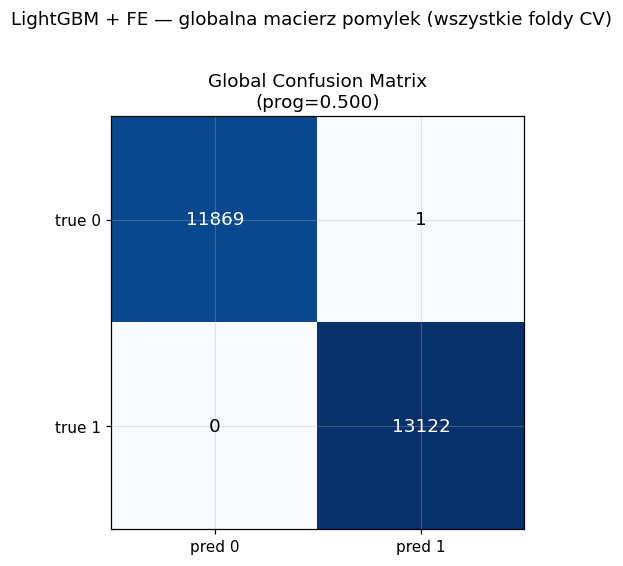

In [126]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
# Fold proba z eval_cv to sumy po foldach cross-validation. Mozemy je po prostu zsumowac dla calego obrazka
y_all, p_all = [], []
for fold_name, (y, p) in fold_proba_lgb.items():
    y_all.extend(y)
    p_all.extend(p)

# Optymalny prog uśredniony (lub arbitralnie 0.5)
y_all = np.array(y_all)
pred_all = (np.array(p_all) >= 0.5).astype(int)

cm = confusion_matrix(y_all, pred_all, labels=[0, 1])
im = axes.imshow(cm, cmap='Blues', vmin=0)
axes.set_xticks([0, 1]); axes.set_yticks([0, 1])
axes.set_xticklabels(['pred 0', 'pred 1'])
axes.set_yticklabels(['true 0', 'true 1'])
axes.set_title(f'Global Confusion Matrix\n(prog=0.500)')
for i in range(2):
    for j in range(2):
        axes.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=12)
plt.suptitle('LightGBM + FE — globalna macierz pomylek (wszystkie foldy CV)', y=1.02)
plt.tight_layout()
plt.show()


## Krok 11 — Końcowe porównanie (kryterium 7)

Wszystkie 4 metody, wszystkie 3 foldy, identyczne metryki.

In [127]:
def add_calibrated_metrics(results, fold_proba, chosen_thr):
    out = results.copy().set_index('fold')
    cal = eval_with_thresholds(fold_proba, chosen_thr).set_index('fold')
    out['f1_calib'] = cal['f1']
    out['precision_calib'] = cal['precision']
    out['recall_calib'] = cal['recall']
    return out.reset_index()

# Kalibracja takze dla baseline (osobna pula progu)
thr_base = calibrate_threshold(fold_proba_base)

per_fold = pd.concat({
    'Baseline (raw, bez FE)':        add_calibrated_metrics(results_base, fold_proba_base, thr_base),
    'XGBoost + FE':                  add_calibrated_metrics(results_xgb,  fold_proba_xgb,  thr_xgb),
    'LightGBM + FE':                 add_calibrated_metrics(results_lgb,  fold_proba_lgb,  thr_lgb),
    'IsolationForest (tylko czyste)': add_calibrated_metrics(results_if,   fold_proba_if,   thr_if),
}, names=['method'])
per_fold = per_fold.reset_index(level=0)
per_fold.round(3)


,method,fold,pos_rate,accuracy,precision,recall,f1,roc_auc,f1_calib,precision_calib,recall_calib
0,"Baseline (raw, bez FE)",fold_0,0.525,0.780,0.747,0.879,0.808,0.797,0.812,0.745,0.893
1,"Baseline (raw, bez FE)",fold_1,0.525,0.782,0.744,0.892,0.811,0.794,0.815,0.741,0.905
2,"Baseline (raw, bez FE)",fold_2,0.525,0.788,0.760,0.870,0.811,0.806,0.816,0.756,0.885
3,"Baseline (raw, bez FE)",fold_3,0.525,0.783,0.750,0.879,0.810,0.793,0.811,0.745,0.889
0,XGBoost + FE,fold_0,0.525,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
1,XGBoost + FE,fold_1,0.525,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
2,XGBoost + FE,fold_2,0.525,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
3,XGBoost + FE,fold_3,0.525,1.000,1.000,0.999,1.000,1.000,1.000,1.000,1.000
0,LightGBM + FE,fold_0,0.525,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
1,LightGBM + FE,fold_1,0.525,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [128]:
summary = per_fold.groupby('method').agg(
    mean_f1_05=('f1','mean'),
    mean_f1_calibrated=('f1_calib','mean'),
    mean_auc=('roc_auc','mean'),
    mean_precision_calibrated=('precision_calib','mean'),
    mean_recall_calibrated=('recall_calib','mean'),
).round(3).sort_values('mean_f1_calibrated', ascending=False)
summary


,mean_f1_05,mean_f1_calibrated,mean_auc,mean_precision_calibrated,mean_recall_calibrated
method,,,,,
XGBoost + FE,1.000,1.000,1.000,1.000,1.000
LightGBM + FE,1.000,1.000,1.000,1.000,1.000
"Baseline (raw, bez FE)",0.810,0.813,0.798,0.747,0.893
IsolationForest (tylko czyste),0.073,0.700,0.540,0.558,0.942


## Krok 12 — feature importance

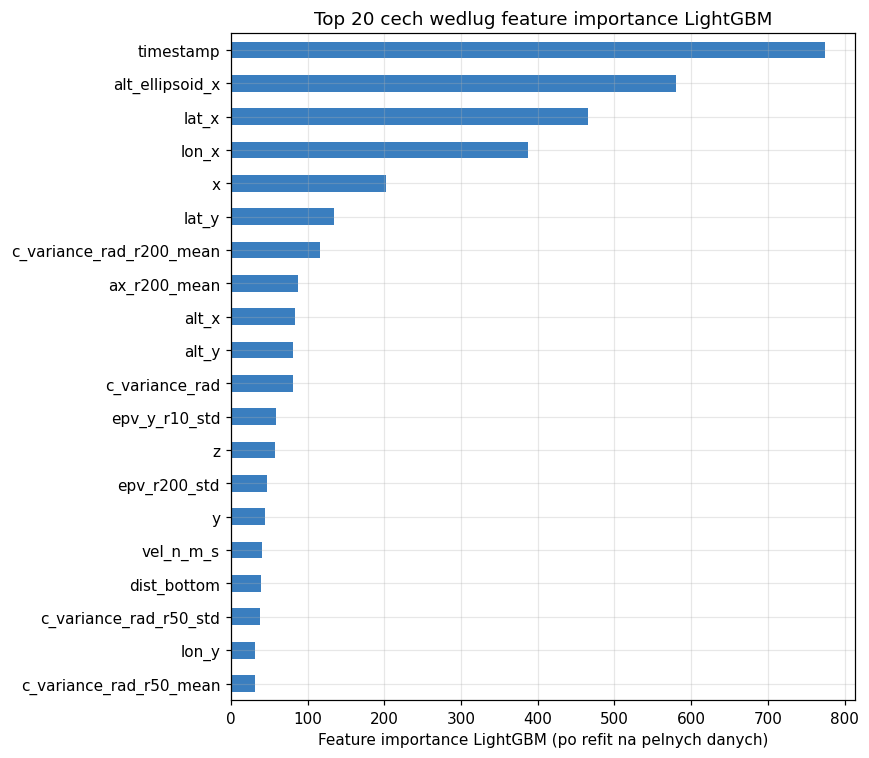

timestamp                   775
alt_ellipsoid_x             580
lat_x                       465
lon_x                       387
x                           202
lat_y                       134
c_variance_rad_r200_mean    116
ax_r200_mean                 88
alt_x                        84
alt_y                        81
c_variance_rad               81
epv_y_r10_std                59
z                            57
epv_r200_std                 47
y                            44
vel_n_m_s                    41
dist_bottom                  39
c_variance_rad_r50_std       38
lon_y                        32
c_variance_rad_r50_mean      31
dtype: int32

In [129]:
X_full = data[feature_cols].values
y_full = data['label'].values
sc = StandardScaler().fit(X_full)
m = LGBMClassifier(
    n_estimators=600, learning_rate=0.04, num_leaves=63,
    min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=0.1,
    verbose=-1, random_state=42, n_jobs=-1,
).fit(sc.transform(X_full), y_full)
imp = pd.Series(m.feature_importances_, index=feature_cols).sort_values(ascending=False)
top = imp.head(20)
ax = top[::-1].plot(kind='barh', figsize=(8, 7), color='#3a7ebf')
ax.set_xlabel('Feature importance LightGBM (po refit na pelnych danych)')
ax.set_title('Top 20 cech wedlug feature importance LightGBM')
plt.tight_layout()
plt.show()
top
